In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Importando dados

Conforme especificado na descrição da atividade, importaremos os dados do dataset CIFAR-10  (https://www.tensorflow.org/datasets/catalog/cifar10), também disponível no TensorFlow.

In [ ]:
# carregando dataset
(trainX, trainY), (testX, testY) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


## Preparando os dados

In [ ]:
# Convertendo valores dos pixels em float
trainX = trainX.astype('float32')
testX = testX.astype('float32')

# normalização para escala [0-1]
trainX = trainX / 255.0
testX = testX / 255.0

# transformando a variável alvo (target) para uma codificação one hot
# One-hot encoding
trainY = to_categorical(trainY, 10)
testY = to_categorical(testY, 10)

img_size = (224,224)

# Função de pré-processamento
def preprocess(img, label):
    img = tf.image.resize(img, (224, 224))  # redimensiona
    img = preprocess_input(img)             # normaliza no padrão VGG16
    return img, label

batch_size = 32

# Dataset de treino
train_ds = tf.data.Dataset.from_tensor_slices((trainX, trainY))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Dataset de teste
test_ds = tf.data.Dataset.from_tensor_slices((testX, testY))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Construindo o modelo

Iremos criar o modelo baseado em um pré-treinado VGG16.

In [ ]:
# Carregamos o modelo VGG16 sem as últimas camadas totalmente conectadas (include_top=False)
pre_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Aqui fazemos com que as camadas do modelo pré-treinado não sejam alteradas durante o treino
for layer in pre_model.layers:
  layer.trainable = False

# Criamos então um modelo sequential onde temos o VGG16 seguido das novas camadas conectadas
model = Sequential()

model.add(pre_model)
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(100, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

opt = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
# Checando a estrutura do modelo criado
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     2,508,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,229,258 (65.72 MB)

 Trainable params: 2,514,570 (9.59 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Treinamento do Modelo

In [ ]:
# Treinamento
steps_per_epoch = len(trainX) // batch_size
model.fit(
    train_ds,
    epochs=30,
    steps_per_epoch= steps_per_epoch,
    validation_data=test_ds,
    verbose=1
)



Epoch 1/30
 949/1562 ━━━━━━━━━━━━━━━━━━━━ 3:13:40 19s/step - accuracy: 0.0946 - loss: 2.3383

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.3962 - loss: 5.0021 - val_accuracy: 0.5875 - val_loss: 1.2109
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5438 - loss: 1.3341 - val_accuracy: 0.6054 - val_loss: 1.1349
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5799 - loss: 1.2109 - val_accuracy: 0.6300 - val_loss: 1.0795
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.6002 - loss: 1.1543 - val_accuracy: 0.6438 - val_loss: 1.0665
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6189 - loss: 1.1146 - val_accuracy: 0.6375 - val_loss: 1.0574
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6180 - loss: 1.1015 - val_accuracy: 0.6479 - val_loss: 1.0520
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6394 - loss: 1.0527 - val_accuracy

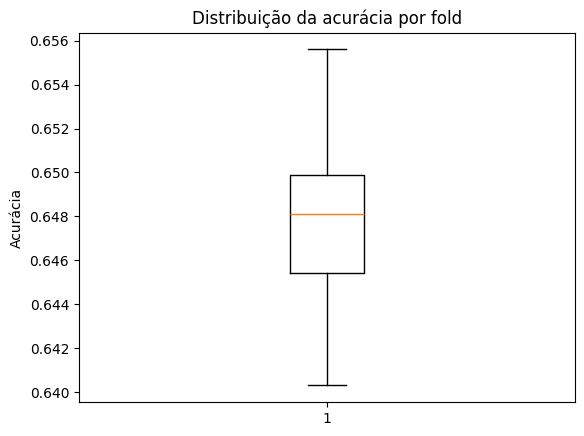

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import KFold

# Carregando e pré-processando os dados
(trainX, trainY), (testX, testY) = cifar10.load_data()
trainX = trainX.astype('float32')
testX = testX.astype('float32')

# Pré-processamento específico para VGG16
trainX = preprocess_input(trainX)
testX = preprocess_input(testX)

trainY = to_categorical(trainY)
testY = to_categorical(testY)

# Função para definir o modelo com VGG16
def define_model():
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(32, 32, 3))
    base_model.trainable = False  # Congela os pesos da base

    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(10, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Callback para early stopping
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Validação cruzada k-fold
scores = []
histories = []
kfold = KFold(5, shuffle=True, random_state=1)

for train_ix, test_ix in kfold.split(trainX):
    model = define_model()

    train_data, train_target = trainX[train_ix], trainY[train_ix]
    val_data, val_target = trainX[test_ix], trainY[test_ix]

    history = model.fit(train_data, train_target,
                        epochs=10, batch_size=32,
                        validation_data=(val_data, val_target),
                        verbose=1, callbacks=[callback])

    _, acc = model.evaluate(val_data, val_target, verbose=0)
    print('> %.3f' % (acc * 100.0))

    scores.append(acc)
    histories.append(history)

# Resultados finais
print('Acurácia: média=%.3f desvio=%.3f' % (np.mean(scores)*100, np.std(scores)*100))
plt.boxplot(scores)
plt.title("Distribuição da acurácia por fold")
plt.ylabel("Acurácia")
plt.show()